In [7]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("combined_prmon_data.csv")

df.head()

,Time,rx_bytes,rx_packets,tx_bytes,tx_packets,wtime,pss,rss,swap,vmem,rchar,read_bytes,wchar,write_bytes,stime,utime,nprocs,nthreads,source
0,1773049120,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,run_normal_1.txt
1,1773049122,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,run_normal_1.txt
2,1773049124,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,run_normal_1.txt
3,1773049126,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,run_normal_1.txt
4,1773049128,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,run_normal_1.txt


In [5]:
df.describe()

,Time,rx_bytes,rx_packets,tx_bytes,tx_packets,wtime,pss,rss,swap,vmem,rchar,read_bytes,wchar,write_bytes,stime,utime,nprocs,nthreads
count,1.370000e+02,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0,137.0
mean,1.773133e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,2.621713e+04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,1.773049e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.773142e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,1.773142e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,1.773142e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,1.773142e+09,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


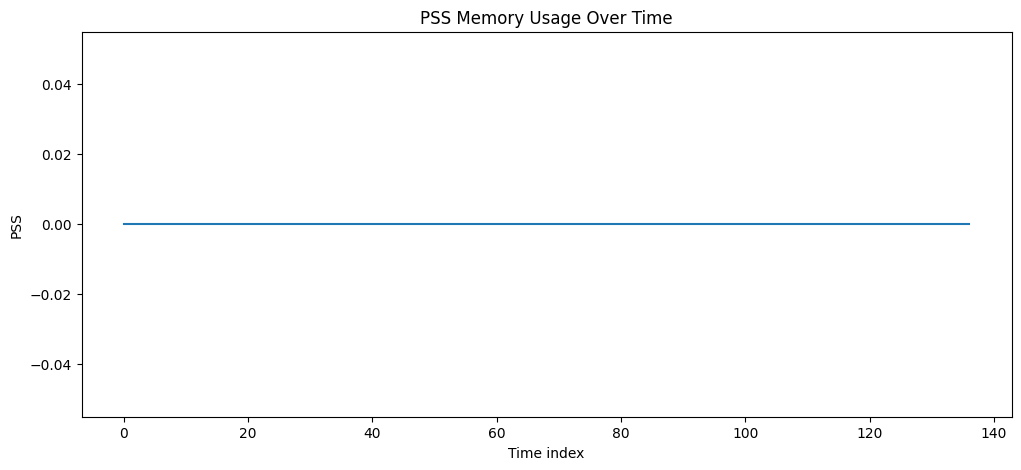

In [8]:


plt.figure(figsize=(12,5))
plt.plot(df["pss"])
plt.title("PSS Memory Usage Over Time")
plt.xlabel("Time index")
plt.ylabel("PSS")
plt.show()

In [9]:
Q1 = df["pss"].quantile(0.25)
Q3 = df["pss"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["iqr_anomaly"] = (df["pss"] < lower) | (df["pss"] > upper)

In [10]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.05)

df["if_anomaly"] = model.fit_predict(df[["pss"]])

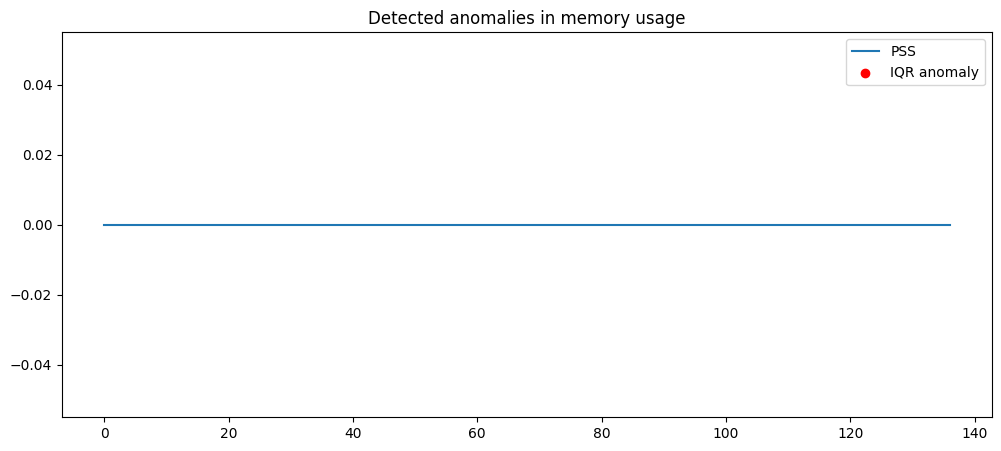

In [11]:
plt.figure(figsize=(12,5))

plt.plot(df["pss"], label="PSS")

anoms = df[df["iqr_anomaly"]]

plt.scatter(anoms.index, anoms["pss"], color="red", label="IQR anomaly")

plt.legend()
plt.title("Detected anomalies in memory usage")
plt.show()

In [14]:
df.columns

Index(['Time', 'rx_bytes', 'rx_packets', 'tx_bytes', 'tx_packets', 'wtime',
       'pss', 'rss', 'swap', 'vmem', 'rchar', 'read_bytes', 'wchar',
       'write_bytes', 'stime', 'utime', 'nprocs', 'nthreads', 'source',
       'iqr_anomaly', 'if_anomaly'],
      dtype='str')